<a href="https://colab.research.google.com/github/Chanbomey/Chanbomey/blob/main/Customer_Churn_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction Using Machine Learning: A Comparative Study of Decision Tree, KNN, and Naive Bayes



**BUSINESS UNDERSTANDING**
<br>
Customer churn refers to the loss of customers when they discontinue their service with a company. It is an important business metric because acquiring new customers is typically more expensive than retaining existing ones. High churn rates may indicate serious issues such as poor service quality, high pricing, or strong competition, which can reduce revenue and profitability. Predicting churn helps companies identify customers who are likely to cancel their service with the business and implement strategies to improve retention.
<br>
<br>
Compared to industries such as banking or healthcare, customer churn in the telecommunications industry is particularly common and costly. This is largely due to high competition, low switching barriers, and comparable pricing and service plans among providers, making it easier for customers to change companies.
<br>
<br>
Therefore, from a business perspective, the customer churn problem can be defined as the task of identifying customers who are at risk of leaving the telecom provider, understanding the reasons behind their potential departure, implementing proactive measures to retain them, and improve long-term profitability.
<br>
<br>
<br>
The customer churn problem can be framed as a binary classification task by defining churn as the target variable with two possible outcomes: 1 or 'Y' (customer churned) and 0 or 'N' (customer retained). The dataset includes historical customer information such as demographic characteristics, service usage data, subscription details, customer category, and tenure. These variables act as predictors, while the churn variable serves as the labeled outcome that the model aims to predict.
<br>
<br>
A binary classification model, such as a Decision Tree, can be trained on the training dataset to learn patterns that distinguish customers who churned from those who did not. Once trained, the model can generate predictions and evaluation metrics, such as precision and recall, which indicate how accurate the churn predictions are and how many actual churners were correctly identified.
<br>
<br>
In essence, the binary classification model transforms the complex problem of customer churn into a measurable and predictive task, enabling businesses to respond proactively and implement timely retention strategies.
<br>
<br>

**DATA UNDERSTANDING**
<br>
VARIABLE DESCRIPTIONS:<br>
cust_id: Customer ID<br>
region: Geographical region of the customer<br>
tenure: Number of months the customer has stayed with the company<br>
age: Customer's age <br>
marital: Customer's marital status<br>
address: Number of years at current address<br>
income: Customer's income<br>
ed: Education level<br>
employ: Years with current employer<br>
retire: Whether the customer is retired<br>
gender: Customer's gender<br>
reside: Number of people residing in the household<br>
tollfree: Whether the customer subscribes to toll-free service<br>
equip: Whether the customer has equipment rental<br>
callcard: Whether the customer uses a calling card<br>
wireless: Whether the customer has wireless service<br>
longmon: Monthly charge for long-distance calls<br>
tollmon: Monthly charge for toll-free service<br>
equipmon: Monthly charge for equipment rental<br>
cardmon: Monthly charge for calling card service<br>
wiremon: Monthly charge for wireless service<br>
longten: Total charge for long-distance calls over entire tenure<br>
tollten: Total charge for toll-free service over entire tenure<br>
equipten: Total charge for equipment rental over entire tenure<br>
cardten: Total charge for calling card service over entire tenure<br>
wireten: Total charge for wireless service over entire tenure<br>
multline: Whether the customer has multiple lines<br>
voice: Whether the customer has voice mail<br>
pager: Whether the customer has a pager<br>
internet: Whether the customer has internet service<br>
callid: Whether the customer has caller ID service<br>
callwait: Whether the customer has call waiting service<br>
forward: Whether the customer has call forwarding service<br>
confer: Whether the customer has conference calling service<br>
ebill: Whether the customer receives electronic billing<br>
loglong: Logarithm of long-distance call charges<br>
lninc: Logarithm of income<br>
custcat: Customer category<br>
churn: Whether the customer churned<br>
<br>
The variables in the dataset relate to the context of the problem at hand by providing information to help us understand customer churn. They all capture different aspects of customer demographics, financial status and stability, service usage, derived measures, and categorical groupings.<br>
<br>
Demographic variables such as age, income, marital status, and education help explain customer preferences, financial capacity, and potential price sensitivity. Financial status and stability-related variables such as tenure, years at current address, and years with current employer may reflect customer loyalty, as more stable customers are often less likely to switch providers.<br>
<br>
Service and subscription variables, including internet service, electronic billing, and monthly charges for long-distance and wireless services, indicate the level of customer engagement and perceived value of the service. Customers who subscribe to more services or spend more may have higher switching costs, whereas low-usage customers may be more likely to churn.<br>
<br>
Derived variables such as loglong and lninc are transformations used to reduce skewness and improve modeling performance.<br>
<br>
Categorical groupings such as region and customer category (custcat) may capture geographic influences and customer segments with different behavioral patterns, which can be indicative of churn risk.<br>
<br>
By analyzing the relationships among these variables, a Decision Tree model can identify patterns associated with churn risk and build a predictive model capable of classifying new, unseen customer data.<br>
<br>

The target variable is **churn** and it is a category variable.<br>

# **1. Upload and clean data**

In [97]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [98]:
# Import libraries
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn import preprocessing

In [99]:
# Read data
customer_churn = pd.read_csv("/content/drive/MyDrive/IS470_data/CutomerChurnData.csv")
customer_churn

,cust_id,region,tenure,age,marital,address,income,ed,employ,retire,...,internet,callid,callwait,forward,confer,ebill,loglong,lninc,custcat,churn
0,C00124,R2,13,44,Y,9,64,E4,5,N,...,N,N,N,Y,N,N,1.308,4.159,C1,Y
1,C00125,R3,68,52,Y,24,116,E1,29,N,...,N,Y,Y,N,Y,N,2.899,4.754,C3,N
2,C00126,R2,23,30,Y,9,30,E1,2,N,...,N,Y,N,Y,Y,N,1.841,3.401,C3,N
3,C00127,R3,45,22,Y,2,19,E2,4,N,...,Y,N,Y,N,N,Y,2.389,2.944,C2,Y
4,C00128,R3,45,59,Y,7,166,E4,31,N,...,N,Y,Y,Y,Y,N,2.277,5.112,C3,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,C01119,R1,50,43,N,6,27,E3,4,N,...,N,Y,Y,Y,Y,N,2.708,3.296,C3,N
996,C01120,R1,34,52,Y,2,106,E2,19,N,...,Y,Y,N,Y,Y,N,1.599,4.663,C3,N
997,C01121,R1,15,46,Y,17,63,E5,1,N,...,Y,Y,N,Y,Y,Y,1.308,4.143,C4,Y
998,C01122,R1,7,34,N,2,22,E5,5,N,...,N,N,N,N,N,N,1.537,3.091,C1,N


In [100]:
# Show all the heading
customer_churn.keys()

Index(['cust_id', 'region', 'tenure', 'age', 'marital', 'address', 'income',
       'ed', 'employ', 'retire', 'gender', 'reside', 'tollfree', 'equip',
       'callcard', 'wireless', 'longmon', 'tollmon', 'equipmon', 'cardmon',
       'wiremon', 'longten', 'tollten', 'equipten', 'cardten', 'wireten',
       'multline', 'voice', 'pager', 'internet', 'callid', 'callwait',
       'forward', 'confer', 'ebill', 'loglong', 'lninc', 'custcat', 'churn'],
      dtype='object')

In [101]:
# Examine the number of rows and columns
customer_churn.shape

(1000, 39)

In [102]:
# Examine missing value
customer_churn.isnull().sum()

,0
cust_id,0
region,0
tenure,0
age,0
marital,0
address,0
income,0
ed,0
employ,0
retire,0


Missing values were examined using customer_churn.isnull().sum(). The results show that no variables contain missing observations, indicating that the dataset is complete and clean.

In [103]:
# Examine variable type
customer_churn.dtypes

,0
cust_id,object
region,object
tenure,int64
age,int64
marital,object
address,int64
income,int64
ed,object
employ,int64
retire,object


In [104]:
# Display all numeric variables
customer_churn.select_dtypes(include=['number'])

,tenure,age,address,income,employ,reside,longmon,tollmon,equipmon,cardmon,wiremon,longten,tollten,equipten,cardten,wireten,loglong,lninc
0,13,44,9,64,5,2,3.70,0.00,0.0,7.50,0.0,37.45,0.00,0.00,110,0.0,1.308,4.159
1,68,52,24,116,29,2,18.15,18.00,0.0,30.25,0.0,1300.60,1247.20,0.00,2150,0.0,2.899,4.754
2,23,30,9,30,2,4,6.30,0.00,0.0,0.00,0.0,157.05,0.00,0.00,0,0.0,1.841,3.401
3,45,22,2,19,4,5,10.90,0.00,0.0,8.75,0.0,504.50,0.00,0.00,415,0.0,2.389,2.944
4,45,59,7,166,31,5,9.75,28.50,0.0,12.00,0.0,449.05,1240.15,0.00,505,0.0,2.277,5.112
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,50,43,6,27,4,1,15.00,45.25,0.0,52.75,0.0,817.85,2320.25,0.00,2645,0.0,2.708,3.296
996,34,52,2,106,19,2,4.95,19.00,0.0,13.50,0.0,153.50,649.35,0.00,430,0.0,1.599,4.663
997,15,46,17,63,1,2,3.70,16.50,42.5,0.00,33.1,40.55,207.35,547.95,0,475.3,1.308,4.143
998,7,34,2,22,5,1,4.65,0.00,25.6,0.00,0.0,29.35,0.00,179.10,0,0.0,1.537,3.091


In [105]:
# Display all categorical variables
customer_churn.select_dtypes(include=['category'])

""
0
1
2
3
4
...
995
996
997
998


In [106]:
# Change categorical variables to "category"
customer_churn['cust_id']  = customer_churn['cust_id'].astype('category')
customer_churn['region']   = customer_churn['region'].astype('category')
customer_churn['marital']  = customer_churn['marital'].astype('category')
customer_churn['ed']       = customer_churn['ed'].astype('category')
customer_churn['retire']   = customer_churn['retire'].astype('category')
customer_churn['gender']   = customer_churn['gender'].astype('category')
customer_churn['tollfree'] = customer_churn['tollfree'].astype('category')
customer_churn['equip']    = customer_churn['equip'].astype('category')
customer_churn['callcard'] = customer_churn['callcard'].astype('category')
customer_churn['wireless'] = customer_churn['wireless'].astype('category')
customer_churn['multline'] = customer_churn['multline'].astype('category')
customer_churn['voice']    = customer_churn['voice'].astype('category')
customer_churn['pager']    = customer_churn['pager'].astype('category')
customer_churn['internet'] = customer_churn['internet'].astype('category')
customer_churn['callid']   = customer_churn['callid'].astype('category')
customer_churn['callwait'] = customer_churn['callwait'].astype('category')
customer_churn['forward']  = customer_churn['forward'].astype('category')
customer_churn['confer']   = customer_churn['confer'].astype('category')
customer_churn['ebill']    = customer_churn['ebill'].astype('category')
customer_churn['custcat']  = customer_churn['custcat'].astype('category')
customer_churn['churn']    = customer_churn['churn'].astype('category')

In [107]:
# Examine variable type
customer_churn.dtypes

,0
cust_id,category
region,category
tenure,int64
age,int64
marital,category
address,int64
income,int64
ed,category
employ,int64
retire,category


In [108]:
# Drop cust_id variable
customer_churn = customer_churn.drop('cust_id', axis=1)
display(customer_churn.head())

,region,tenure,age,marital,address,income,ed,employ,retire,gender,...,internet,callid,callwait,forward,confer,ebill,loglong,lninc,custcat,churn
0,R2,13,44,Y,9,64,E4,5,N,N,...,N,N,N,Y,N,N,1.308,4.159,C1,Y
1,R3,68,52,Y,24,116,E1,29,N,Y,...,N,Y,Y,N,Y,N,2.899,4.754,C3,N
2,R2,23,30,Y,9,30,E1,2,N,N,...,N,Y,N,Y,Y,N,1.841,3.401,C3,N
3,R3,45,22,Y,2,19,E2,4,N,Y,...,Y,N,Y,N,N,Y,2.389,2.944,C2,Y
4,R3,45,59,Y,7,166,E4,31,N,N,...,N,Y,Y,Y,Y,N,2.277,5.112,C3,N


cust_id represents a unique identifier for each customer and does not contain meaningful behavioral or demographic information. Since it has no predictive value and may introduce noise or overfitting, it was excluded from the modeling process.

# **2. Exploratory Data Analysis**

In [109]:
# Generate the correlation matrix of all numeric variables
customer_churn.select_dtypes(include=['number']).corr()

,tenure,age,address,income,employ,reside,longmon,tollmon,equipmon,cardmon,wiremon,longten,tollten,equipten,cardten,wireten,loglong,lninc
tenure,1.000000,0.475715,0.531723,0.260311,0.520837,0.003392,0.707012,0.183964,-0.060533,0.464380,0.122197,0.743025,0.465131,0.305777,0.671865,0.318131,0.834781,0.317191
age,0.475715,1.000000,0.648858,0.375201,0.667698,-0.219699,0.399567,0.108035,-0.087599,0.357184,0.035937,0.423347,0.255622,0.057875,0.429788,0.102269,0.423413,0.408809
address,0.531723,0.648858,1.000000,0.269532,0.473235,-0.174909,0.494289,0.130641,-0.074199,0.343841,0.019519,0.519205,0.298040,0.079887,0.465525,0.110926,0.488836,0.282395
income,0.260311,0.375201,0.269532,1.000000,0.611087,-0.099252,0.216594,0.169940,-0.035326,0.176103,0.098222,0.232504,0.249691,0.012987,0.203118,0.123740,0.225944,0.850498
employ,0.520837,0.667698,0.473235,0.611087,1.000000,-0.104103,0.457547,0.189690,-0.159914,0.344947,0.017875,0.489562,0.342825,-0.001937,0.443235,0.099254,0.456350,0.668575
reside,0.003392,-0.219699,-0.174909,-0.099252,-0.104103,1.000000,-0.008030,0.076684,-0.009835,0.020076,0.048737,-0.011136,0.018758,0.009561,0.005268,0.038325,-0.003076,-0.113496
longmon,0.707012,0.399567,0.494289,0.216594,0.457547,-0.008030,1.000000,0.132686,-0.043699,0.465429,0.070288,0.980346,0.345019,0.202495,0.648830,0.216786,0.871126,0.250000
tollmon,0.183964,0.108035,0.130641,0.169940,0.189690,0.076684,0.132686,1.000000,0.070591,0.336954,0.462594,0.133696,0.801161,0.140615,0.235686,0.448021,0.173010,0.190633
equipmon,-0.060533,-0.087599,-0.074199,-0.035326,-0.159914,-0.009835,-0.043699,0.070591,1.000000,-0.003648,0.534480,-0.043922,0.064685,0.811252,-0.013271,0.425448,-0.061391,0.031592
cardmon,0.464380,0.357184,0.343841,0.176103,0.344947,0.020076,0.465429,0.336954,-0.003648,1.000000,0.267844,0.485595,0.375519,0.164978,0.878379,0.283412,0.453414,0.215430


The correlation matrix of the numerical variables reveals several strong positive relationships and no strong negative relationships. <br>
Extremely high correlations are observed between monthly and total charge variables, such as longmon and longten (0.980), cardmon and cardten (0.878), wiremon and wireten (0.895), and equipmon and equipten (0.811). These strong relationships are expected, as total charges accumulate over time based on monthly usage.

Similarly, strong correlations are observed between original variables and their log-transformed counterparts, including income and lninc (0.850), as well as longmon and loglong (0.871). This confirms that the log variables represent scaled transformations of the original measures.

Other notable relationships include the strong positive correlation between tenure and longten (0.743), indicating that customers with longer tenure naturally accumulate higher total spending. Additionally, age and employ (0.668) show a strong positive relationship, suggesting that older customers tend to have more years of employment. The correlation between employ and income (0.611) further reflects that longer employment duration is associated with higher income levels.

An interesting finding is the strong positive correlation between tenure and longmon (0.707), suggesting that customers who have remained with the company longer also tend to spend more on long-distance services monthly. This relationship may need further visualization to better understand their association and understanding for customer behavior.

Text(0.5, 1.0, 'Countplot of churn in customer_churn data set')

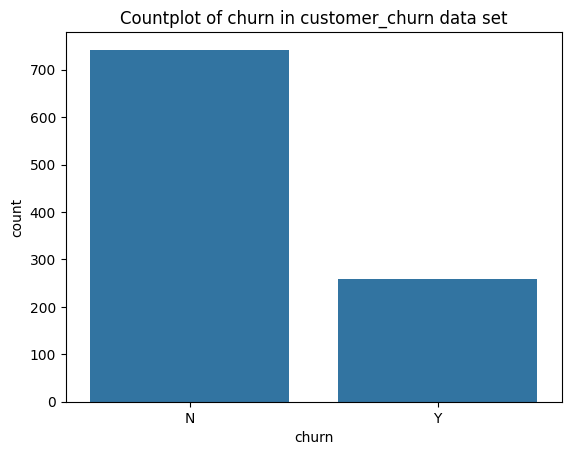

In [110]:
# Countplot a categorical variable: churn
snsplot = sns.countplot(x = 'churn', data = customer_churn)
snsplot.set_title("Countplot of churn in customer_churn data set")

The countplot displays the distribution of the categorical variable churn, showing the number of customers who stayed (N) versus those who churned (Y). The chart indicates that the majority of customers fall into the non-churn category, with substantially more observations than the churn category.

The data is imbalanced, as non-churners significantly outnumber churners. Such class imbalance can bias predictive models toward the majority class, potentially resulting in high overall accuracy but poor performance in correctly identifying churn cases.

(0.0, 100.0)

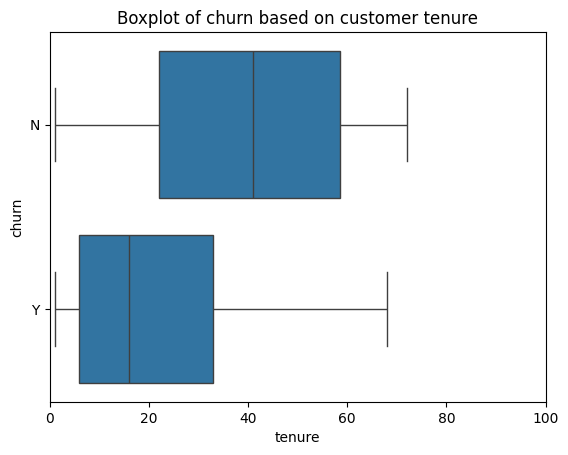

In [111]:
# Examine relationships between numeric and categorical variables: churn by tenure
snsplot = sns.boxplot(x='tenure', y= 'churn', data = customer_churn)
snsplot.set_title("Boxplot of churn based on customer tenure")
snsplot.set_xlim([0, 100])

The boxplot compares the distribution of customer tenure between customers who churned (Y) and those who did not churn (N).

From the plot, customers who did not churn have a noticeably higher median tenure compared to customers who churned. The interquartile range for non-churners is also shifted toward higher tenure values, indicating that a substantial portion of retained customers have been with the company for a longer period. In contrast, churned customers tend to have lower tenure overall, with a lower median and a distribution concentrated in the earlier months.

Although there is some overlap between the groups, the overall pattern suggests that customers with shorter tenure are more likely to churn, whereas those who have stayed longer are more likely to remain with the company.

Text(0.5, 1.0, 'Boxplot of churn based on customer income')

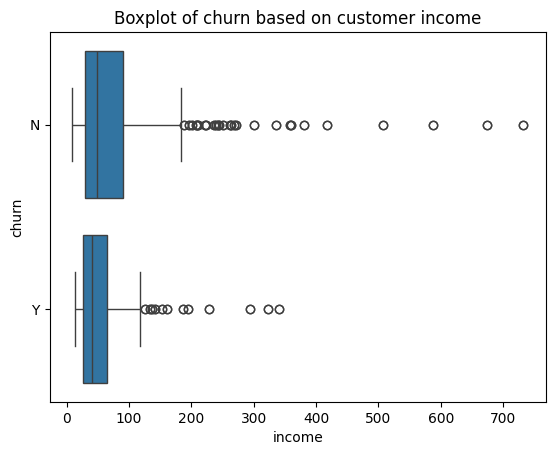

In [112]:
# Examine relationships between numeric and categorical variables: churn by income
snsplot = sns.boxplot(x='income', y= 'churn', data = customer_churn)
snsplot.set_title("Boxplot of churn based on customer income")



The boxplot compares the distribution of customer income between churned and non churned customers.

Both groups show a similar median income and overlapping interquartile ranges, indicating that income levels are relatively comparable between customers who stayed and those who churned.

However, the distribution is right-skewed in both groups, with several high-income outliers visible, particularly among non-churners. While non-churners appear to have slightly higher income variability and more extreme high-income values, the substantial overlap between the two boxplots suggests that income alone may not be a strong distinguishing factor for churn.

Text(0.5, 1.0, 'Churn Distribution based on customer education')

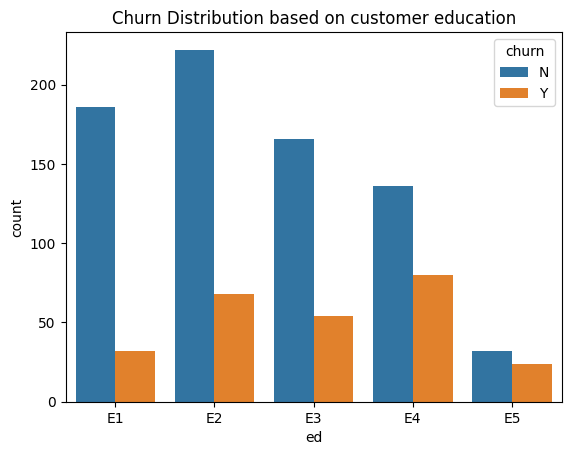

In [113]:
# Countplot to visualize churn distribution based on customer's education
snsplot = sns.countplot(x = 'ed', hue = 'churn', data = customer_churn)
snsplot.set_title("Churn Distribution based on customer education")

The countplot shows the distribution of churn across customer categories from E1 to E5.

In all categories, non-churned customers (N) outnumber churned customers (Y), indicating generally strong retention across segments. Categories E1, E2, and E3 have the largest customer bases, while E5 has the smallest. Notably, category E4 exhibits a relatively higher proportion of churn, as the gap between retained and churned customers is smaller compared to other groups.

Overall, the plot suggests that churn varies by customer education category, with E4 appearing more prone to churn. This indicates that customer's education category may be a useful factor in identifying high-risk segments for targeted retention strategies.

(0.0, 120.0)

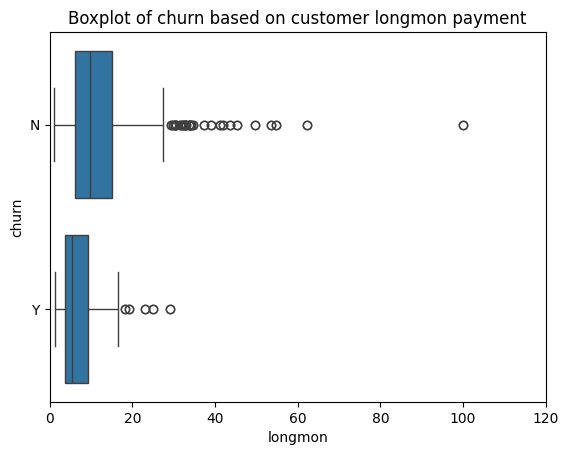

In [114]:
# Examine relationships between numeric and categorical variables: churn by longmon payment
snsplot = sns.boxplot(x='longmon', y= 'churn', data = customer_churn)
snsplot.set_title("Boxplot of churn based on customer longmon payment")
snsplot.set_xlim([0, 120])

The boxplot compares long-distance monthly charges(longmon) between churned(Y) and non-churned(N) customers.

Non-churned customers exhibit a slightly higher median long-distance payment and a wider distribution compared to churned customers. Churned customers generally have lower median longmon values, with their payments more concentrated in the lower range. Although there is overlap between the two groups, non-churners show greater variability and more high-value outliers.

Overall, the plot suggests that customers with lower long-distance monthly charges may be likely to churn, while those with higher longmon payments tend to remain with the company.

Text(0.5, 1.0, 'Churn Distribution based on Internet Service')

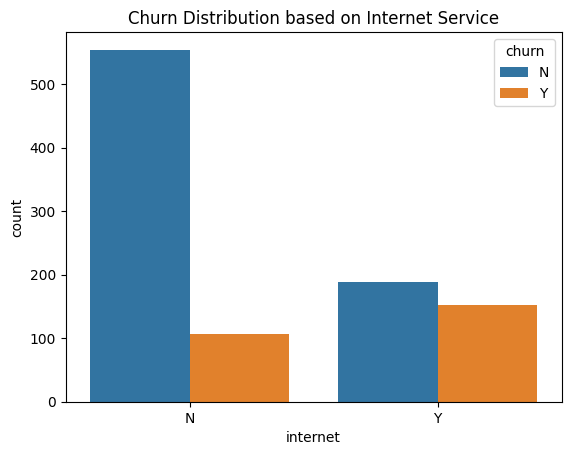

In [115]:
# Countplot to visualize churn distribution based on internet service
snsplot = sns.countplot(x = 'internet', hue = 'churn', data = customer_churn)
snsplot.set_title("Churn Distribution based on Internet Service")

The countplot shows the distribution of churn based on whether customers subscribe to internet service (N= No internet, Y= Yes internet).

Customers without internet service have a much larger number of non-churners compared to churners, indicating relatively strong retention in this group. In contrast, among customers with internet service, the gap between non-churners and churners is small, and the number of churned customers is noticeably higher.

This suggests that customers who subscribe to internet service are more prone to churn compared to those who do not. Therefore, internet service usage appears to be associated with a higher likelihood of churn and may be an important factor in predicting customer retention.

Text(0.5, 1.0, "Churn Distribution based on customer's retirement")

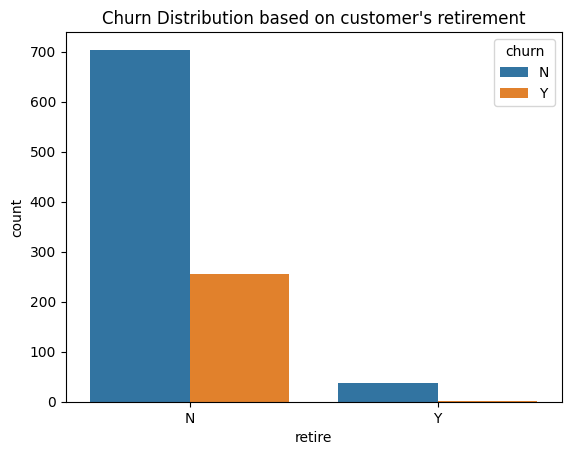

In [116]:
# Countplot to visualize churn distribution based on customer's retirement status
snsplot = sns.countplot(x = 'retire', hue = 'churn', data = customer_churn)
snsplot.set_title("Churn Distribution based on customer's retirement")

The countplot displays the distribution of churn based on retirement status(N= not retired, Y= retired).

The majority of customers are not retired, and within this group, non-churners significantly outnumber churners. The retired segment is much smaller, and very small number of churn cases are observed in this group. As a result, most churn cases occur among non-retired customers primarily because they represent the largest portion of the dataset, reflecting an overall class imbalance.

Overall, retirement status does not show a clear pattern of higher churn. Given the small size of the retired group and the imbalance in the churn variable, further analysis using balanced data would be necessary to determine whether retirement status meaningfully influences churn.

Text(0.5, 1.0, 'Churn Distribution based on customer category')

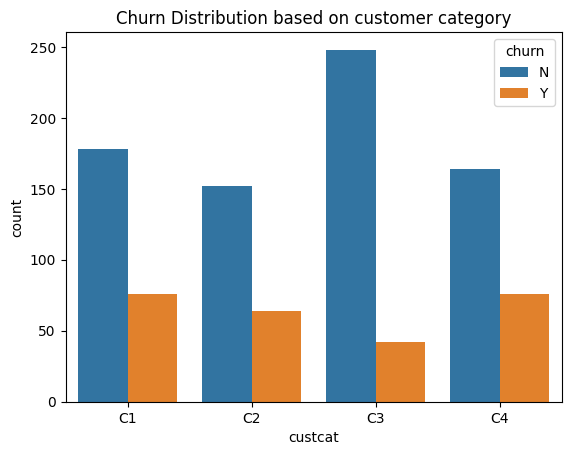

In [117]:
# Countplot to visualize churn distribution based on customer category
snsplot = sns.countplot(x = 'custcat', hue = 'churn', data = customer_churn)
snsplot.set_title("Churn Distribution based on customer category")

The chart shows the distribution of churn across different customer categories. In all categories, non-churn customers outnumber churn customers, indicating that most customers remain with the company. However, category C3 has the lowest proportion of churn, suggesting higher customer retention, while categories C1 and C4 exhibit relatively higher churn levels. This indicates that customer category is an important factor influencing churn behavior and may help identify high-risk customer segments.

Text(0.5, 1.0, 'Boxplot of churn based on total charge for calling card service over entire tenure')

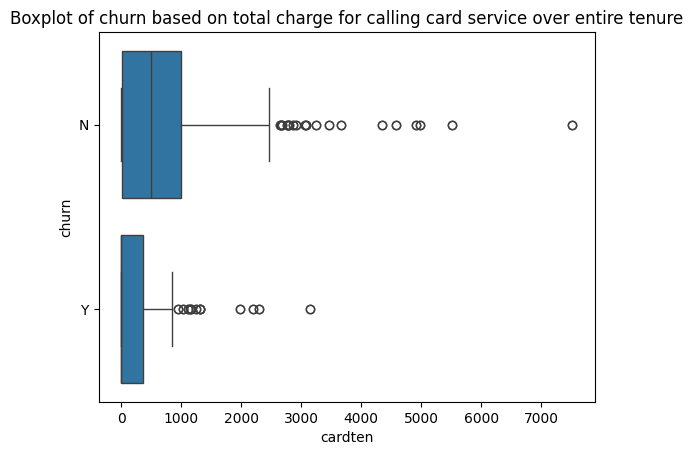

In [36]:
# Examine relationships between numeric and categorical variables: churn by cardten
snsplot = sns.boxplot(x='cardten', y= 'churn', data = customer_churn)
snsplot.set_title("Boxplot of churn based on total charge for calling card service over entire tenure")

# **3. Partition the Dataset**

In [20]:
# Create dummy variables
customer_churn = pd.get_dummies(customer_churn, columns=['region','marital','ed','retire','gender','tollfree','equip','callcard','wireless','multline','voice','pager','internet','callid','callwait','forward','confer','ebill','custcat'], drop_first=True, dtype= int)
customer_churn

,tenure,age,address,income,employ,reside,longmon,tollmon,equipmon,cardmon,...,pager_Y,internet_Y,callid_Y,callwait_Y,forward_Y,confer_Y,ebill_Y,custcat_C2,custcat_C3,custcat_C4
0,13,44,9,64,5,2,3.70,0.00,0.0,7.50,...,0,0,0,0,1,0,0,0,0,0
1,68,52,24,116,29,2,18.15,18.00,0.0,30.25,...,0,0,1,1,0,1,0,0,1,0
2,23,30,9,30,2,4,6.30,0.00,0.0,0.00,...,0,0,1,0,1,1,0,0,1,0
3,45,22,2,19,4,5,10.90,0.00,0.0,8.75,...,0,1,0,1,0,0,1,1,0,0
4,45,59,7,166,31,5,9.75,28.50,0.0,12.00,...,0,0,1,1,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,50,43,6,27,4,1,15.00,45.25,0.0,52.75,...,0,0,1,1,1,1,0,0,1,0
996,34,52,2,106,19,2,4.95,19.00,0.0,13.50,...,0,1,1,0,1,1,0,0,1,0
997,15,46,17,63,1,2,3.70,16.50,42.5,0.00,...,1,1,1,0,1,1,1,0,0,1
998,7,34,2,22,5,1,4.65,0.00,25.6,0.00,...,0,0,0,0,0,0,0,0,0,0


In [21]:
# Examine the porportion of target variable for data set
target = customer_churn['churn']
print(target.value_counts(normalize=True))

churn
N    0.742
Y    0.258
Name: proportion, dtype: float64


In [22]:
# Partition the data
predictors = customer_churn.drop(['churn'],axis=1)
predictors_train, predictors_test, target_train, target_test = train_test_split(predictors, target, test_size=0.3, random_state=0)
print(predictors_train.shape, predictors_test.shape, target_train.shape, target_test.shape)

(700, 43) (300, 43) (700,) (300,)


In [23]:
# Taking steps to balance the train data
# Combine predictors_train and target_train into a single DataFrame
combined_train_df = pd.concat([predictors_train, target_train], axis=1)

# Separate majority and minority classes
majority_df = combined_train_df[combined_train_df['churn'] == 'N']
minority_df = combined_train_df[combined_train_df['churn'] == 'Y']

# Undersample the majority class randomly
undersampled_majority = majority_df.sample(n=len(minority_df), random_state=5)

# Combine the undersampled majority class and the minority class
undersampled_data = pd.concat([undersampled_majority, minority_df])

# Shuffle the combined DataFrame to ensure randomness
balanced_data = undersampled_data.sample(frac=1, random_state=5)

# Split the balanced_data into predictors_train and target_train
predictors_train = balanced_data.drop(columns=['churn'])
target_train = balanced_data['churn']

In [24]:
# Examine the porportion of target variable for train set
print(target_train.value_counts(normalize=True), target_train.shape)

churn
N    0.5
Y    0.5
Name: proportion, dtype: float64 (342,)


In [25]:
# Examine the porportion of target variable for testing data set
print(target_test.value_counts(normalize=True))

churn
N    0.71
Y    0.29
Name: proportion, dtype: float64


# **4. Build Model Prediction**

## I. Decision Tree Model Prediction

### Hypertuning `max_depth` for Decision Tree

In [30]:
best_max_depth = 0
best_DT_accuracy = 0

# Loop through a range of max_depth values
for max_depth_value in range(1, 21):  # Testing max_depth from 1 to 20
    modelDT = DecisionTreeClassifier(criterion="entropy", random_state=1, max_depth=max_depth_value)
    modelDT.fit(predictors_train, target_train)

    prediction_on_test = modelDT.predict(predictors_test)
    report = classification_report(target_test, prediction_on_test, output_dict=True)

    # Get the accuracy
    accuracy = report['accuracy']

    print(f"\n----- max_depth = {max_depth_value} -----")
    print(classification_report(target_test, prediction_on_test))

    if  accuracy > best_DT_accuracy:
        best_DT_accuracy = accuracy
        best_max_depth = max_depth_value

print(f"\nBest max_depth for Decision Tree: {best_max_depth} with accuracy: {best_DT_accuracy:.4f}")


----- max_depth = 1 -----
              precision    recall  f1-score   support

           N       0.81      0.83      0.82       213
           Y       0.55      0.52      0.53        87

    accuracy                           0.74       300
   macro avg       0.68      0.67      0.67       300
weighted avg       0.73      0.74      0.73       300


----- max_depth = 2 -----
              precision    recall  f1-score   support

           N       0.81      0.83      0.82       213
           Y       0.55      0.52      0.53        87

    accuracy                           0.74       300
   macro avg       0.68      0.67      0.67       300
weighted avg       0.73      0.74      0.73       300


----- max_depth = 3 -----
              precision    recall  f1-score   support

           N       0.78      0.76      0.77       213
           Y       0.45      0.47      0.46        87

    accuracy                           0.68       300
   macro avg       0.61      0.62      0.61    

### Max_Depth = 7

In [31]:
# Build a decision tree model on training data with max_depth = 7
model_DT1 = DecisionTreeClassifier(criterion = "entropy", random_state = 1, max_depth = 7)
model_DT1.fit(predictors_train, target_train)

DecisionTreeClassifier(criterion='entropy', max_depth=7, random_state=1)

[Text(0.49122807017543857, 0.9375, 'longten <= 111.275\nentropy = 1.0\nsamples = 342\nvalue = [171, 171]\nclass = No'),
 Text(0.2149122807017544, 0.8125, 'equipten <= 30.875\nentropy = 0.837\nsamples = 146\nvalue = [39, 107]\nclass = Yes'),
 Text(0.3530701754385965, 0.875, 'True  '),
 Text(0.13157894736842105, 0.6875, 'tollmon <= 19.375\nentropy = 0.996\nsamples = 67\nvalue = [31, 36]\nclass = Yes'),
 Text(0.11403508771929824, 0.5625, 'longten <= 30.875\nentropy = 0.979\nsamples = 53\nvalue = [31, 22]\nclass = No'),
 Text(0.07017543859649122, 0.4375, 'custcat_C3 <= 0.5\nentropy = 0.828\nsamples = 23\nvalue = [6, 17]\nclass = Yes'),
 Text(0.05263157894736842, 0.3125, 'equipten <= 25.85\nentropy = 0.61\nsamples = 20\nvalue = [3, 17]\nclass = Yes'),
 Text(0.03508771929824561, 0.1875, 'address <= 0.5\nentropy = 0.485\nsamples = 19\nvalue = [2, 17]\nclass = Yes'),
 Text(0.017543859649122806, 0.0625, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = No'),
 Text(0.05263157894736842, 0.0625

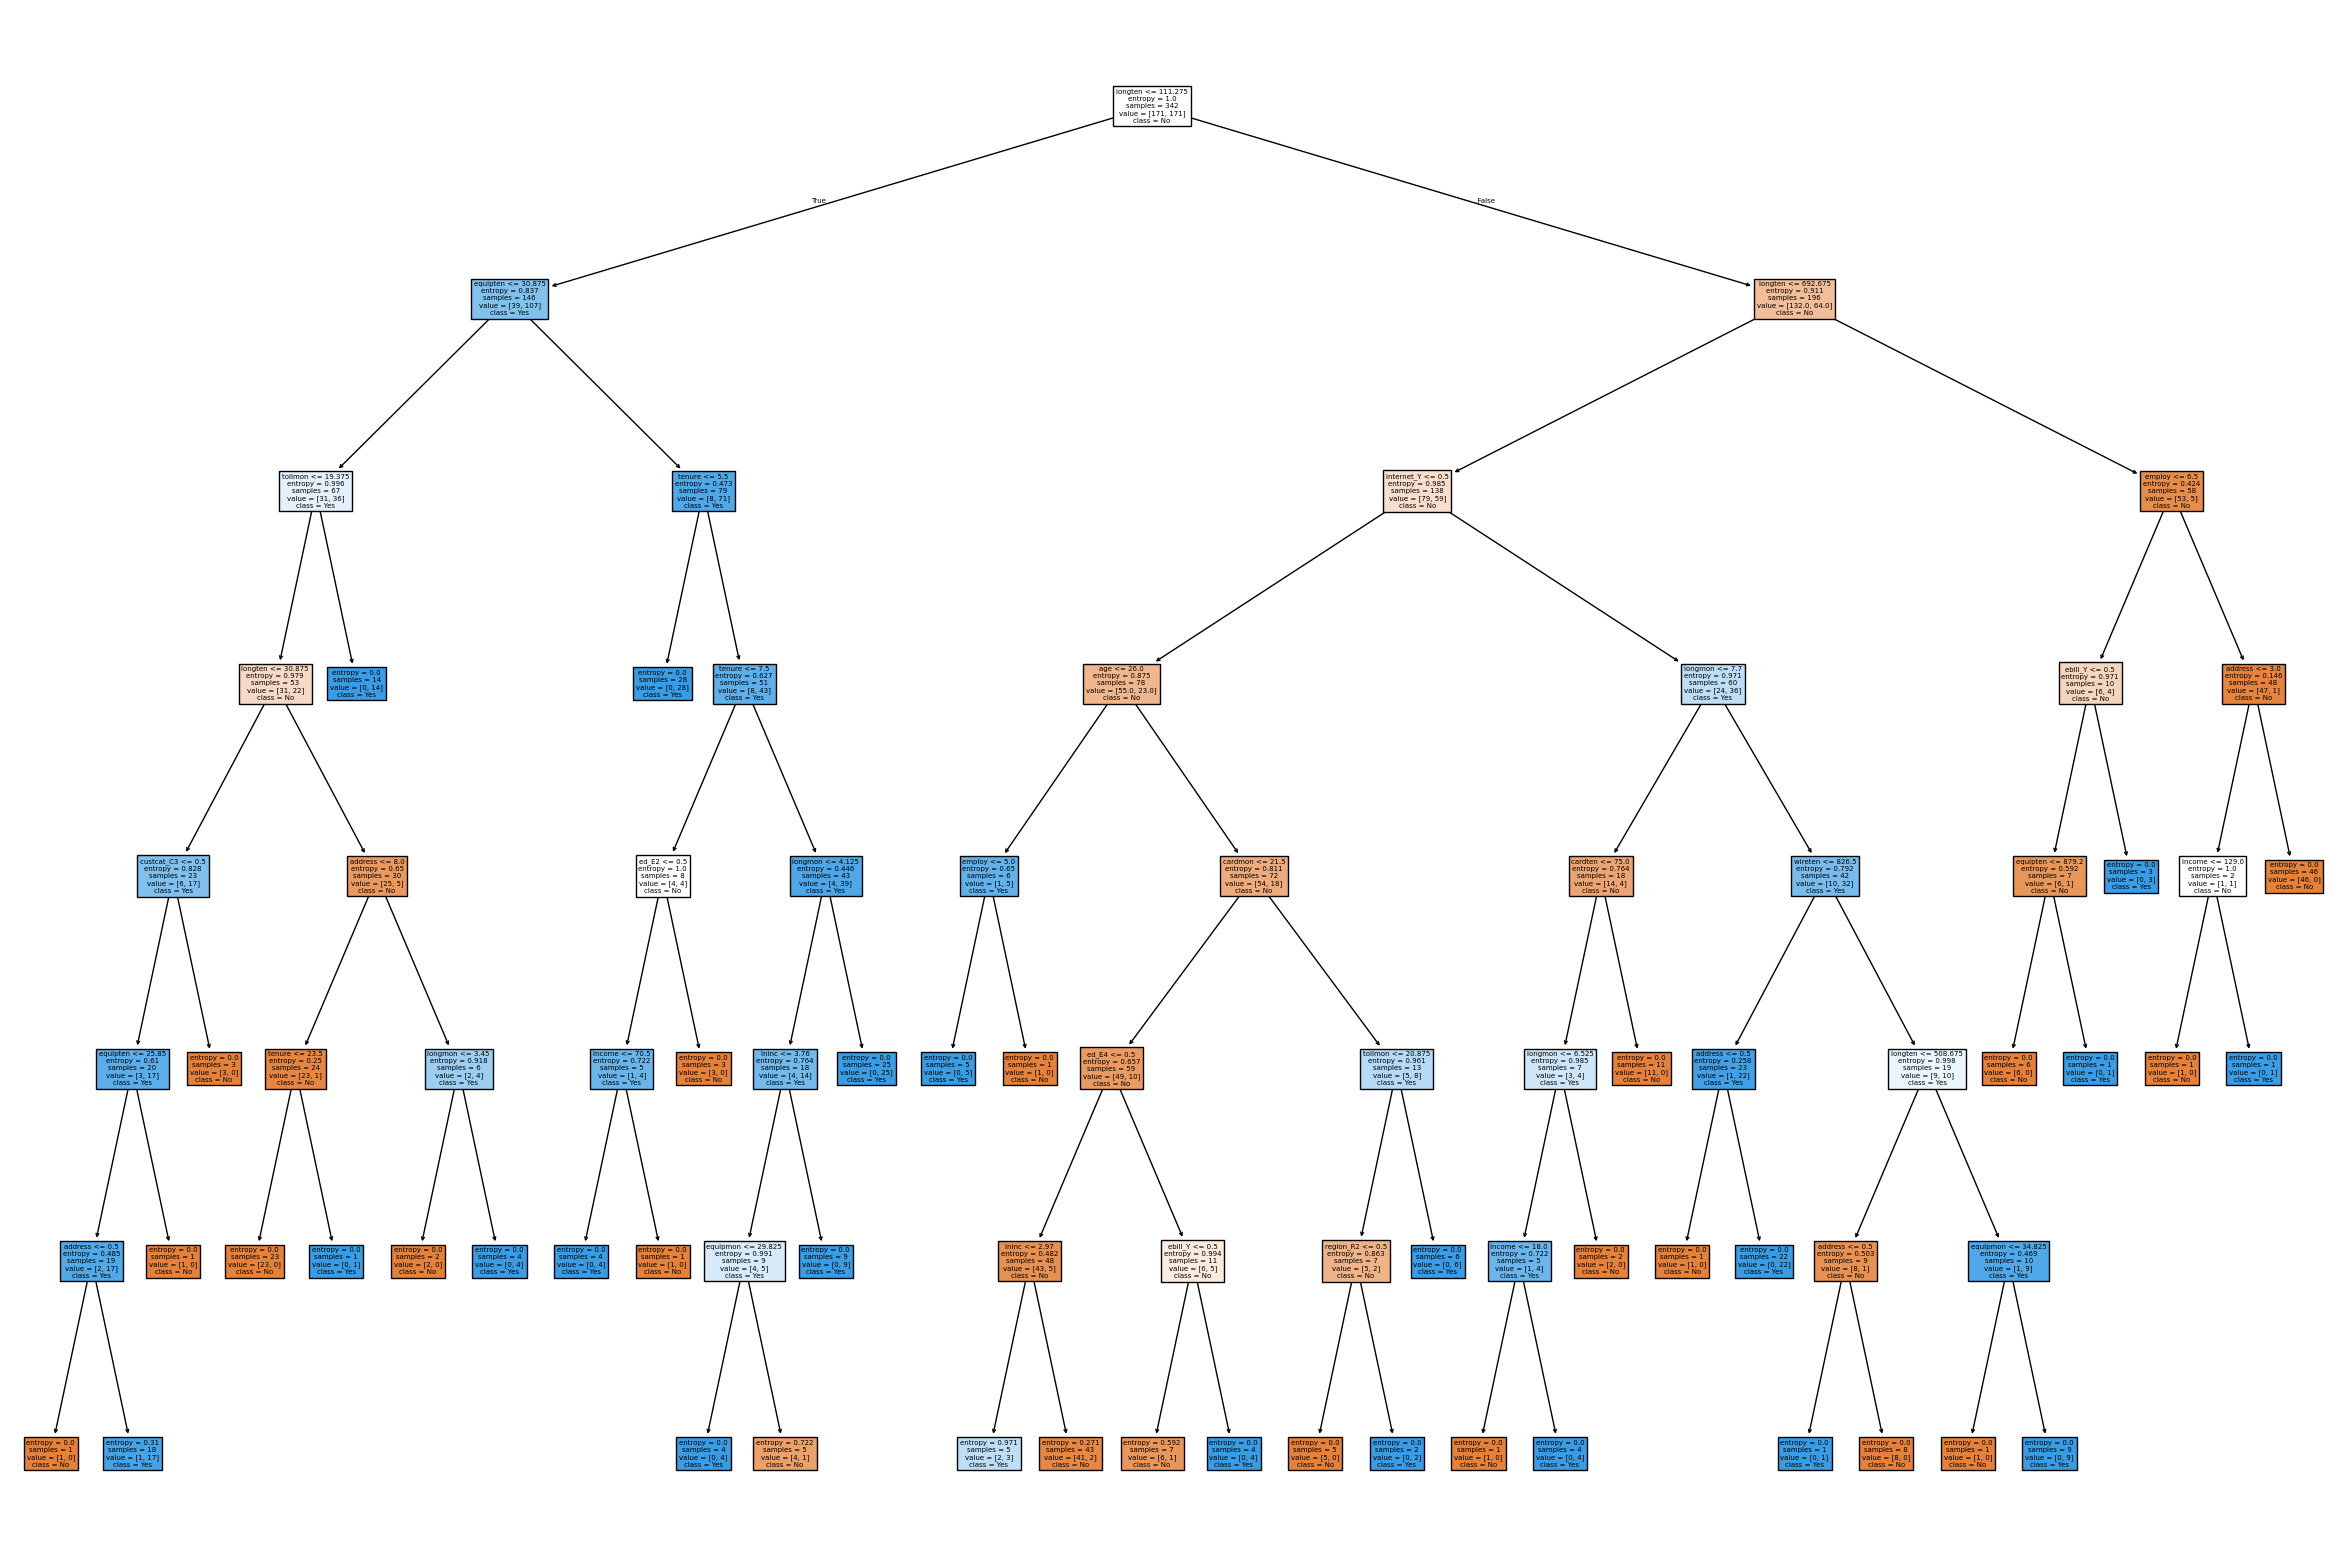

In [32]:
# Plot the tree
fig = plt.figure(figsize=(30,20))
tree.plot_tree(model_DT1,
               feature_names=list(predictors_train.columns),
               class_names=['No','Yes'],
               filled=True)

In [33]:
# Text version of decision tree
print(tree.export_text(model_DT1, feature_names=list(customer_churn.columns)[1:]))

|--- tollten <= 111.28
|   |--- cardten <= 30.88
|   |   |--- equipmon <= 19.38
|   |   |   |--- tollten <= 30.88
|   |   |   |   |--- custcat_C3 <= 0.50
|   |   |   |   |   |--- cardten <= 25.85
|   |   |   |   |   |   |--- income <= 0.50
|   |   |   |   |   |   |   |--- class: N
|   |   |   |   |   |   |--- income >  0.50
|   |   |   |   |   |   |   |--- class: Y
|   |   |   |   |   |--- cardten >  25.85
|   |   |   |   |   |   |--- class: N
|   |   |   |   |--- custcat_C3 >  0.50
|   |   |   |   |   |--- class: N
|   |   |   |--- tollten >  30.88
|   |   |   |   |--- income <= 8.00
|   |   |   |   |   |--- age <= 23.50
|   |   |   |   |   |   |--- class: N
|   |   |   |   |   |--- age >  23.50
|   |   |   |   |   |   |--- class: Y
|   |   |   |   |--- income >  8.00
|   |   |   |   |   |--- tollmon <= 3.45
|   |   |   |   |   |   |--- class: N
|   |   |   |   |   |--- tollmon >  3.45
|   |   |   |   |   |   |--- class: Y
|   |   |--- equipmon >  19.38
|   |   |   |--- class: Y
|   |

The decision tree shows that the most important variable influencing churn is tollten, as it appears at the root node and determines the primary split in the data. This indicates that customer usage or tenure in toll services is the strongest predictor of churn.

Other key variables include cardten and several monthly usage variables such as tollmon, equipmon, cardmon, and wiremon, which appear frequently and influence multiple branches of the tree. These variables suggest that customer engagement and service usage play a major role in predicting churn.

Additionally, income is an important factor, indicating that financial status affects customer behavior. Demographic variables such as age, employment, education, and customer category also contribute to the prediction, although they appear deeper in the tree and are less influential.

Finally, service-related variables like internet usage and e-billing, as well as stability indicators such as residence length, further refine the prediction.

Overall, the model suggests that service usage and tenure are the primary drivers of churn, followed by income and customer characteristics.

In [37]:
# Make predictions on testing data
prediction_on_test = model_DT1.predict(predictors_test)

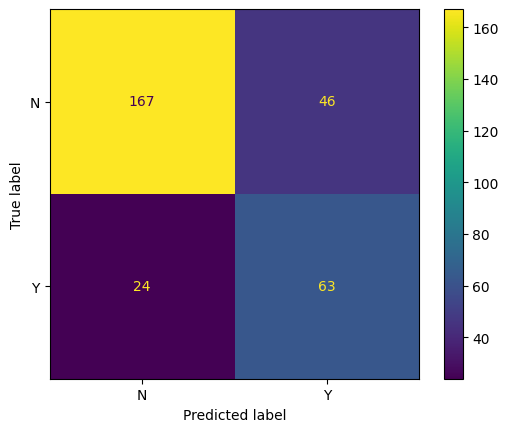

In [38]:
# Examine the evaluation results on testing data: confusion_matrix
cm_DT1 = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(confusion_matrix=cm_DT1, display_labels=model_DT1.classes_).plot()

In [39]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

           N       0.87      0.78      0.83       213
           Y       0.58      0.72      0.64        87

    accuracy                           0.77       300
   macro avg       0.73      0.75      0.73       300
weighted avg       0.79      0.77      0.77       300



The decision tree model achieves an overall accuracy of 0.77, indicating a moderate level of performance. The model performs well in identifying non-churn customers, with high precision (0.87) and good recall (0.78), resulting in a strong F1-score of 0.83.

However, for churn customers, the model shows lower precision (0.58) but relatively higher recall (0.72). This indicates that while the model is able to identify a large proportion of actual churn customers, it also incorrectly classifies many non-churn customers as churn.

Overall, the model is more effective at predicting non-churn customers and tends to over-predict churn, leading to lower precision for the churn class.

## II. K Nearest Neighbor Model Prediction

### Hypertuning `n_neighbors` (K) for K-Nearest Neighbor

In [40]:
best_k = 0
best_KNN_accuracy = 0

# Loop through a range of n_neighbors values (e.g., from 1 to 20, using odd numbers to avoid ties)
for k_value in range(1, 21, 2):  # Testing odd k values from 1 to 19
    modelKNN = KNeighborsClassifier(n_neighbors=k_value)
    modelKNN.fit(predictors_train, target_train)

    prediction_on_test_knn = modelKNN.predict(predictors_test)
    report_knn = classification_report(target_test, prediction_on_test_knn, output_dict=True)

    # Get the accuracy
    KNN_accuracy = report_knn['accuracy']

    print(f"\n----- k = {k_value} -----")
    print(classification_report(target_test, prediction_on_test_knn))

    if  KNN_accuracy > best_KNN_accuracy:
        best_KNN_accuracy = KNN_accuracy
        best_k = k_value

print(f"\nBest k for K-Nearest Neighbor: {best_k}, with accuracy of: {best_KNN_accuracy:.4f}")


----- k = 1 -----
              precision    recall  f1-score   support

           N       0.91      0.70      0.80       213
           Y       0.54      0.84      0.65        87

    accuracy                           0.74       300
   macro avg       0.73      0.77      0.73       300
weighted avg       0.81      0.74      0.75       300


----- k = 3 -----
              precision    recall  f1-score   support

           N       0.81      0.63      0.71       213
           Y       0.42      0.64      0.51        87

    accuracy                           0.64       300
   macro avg       0.62      0.64      0.61       300
weighted avg       0.70      0.64      0.65       300


----- k = 5 -----
              precision    recall  f1-score   support

           N       0.82      0.63      0.71       213
           Y       0.42      0.66      0.51        87

    accuracy                           0.64       300
   macro avg       0.62      0.64      0.61       300
weighted avg     

### Scale the numerical data for KNN

In [56]:
# Identify numerical columns that need scaling
numerical_cols = ['tenure', 'age', 'address', 'income', 'employ', 'reside',
                  'longmon', 'tollmon', 'equipmon', 'cardmon', 'wiremon',
                  'longten', 'tollten', 'equipten', 'cardten', 'wireten',
                  'loglong', 'lninc']

# Initialize the StandardScaler
scaler = preprocessing.StandardScaler()

# Create copies to avoid modifying original predictors_train/test in place before scaling
predictors_train_scaled = predictors_train.copy()
predictors_test_scaled = predictors_test.copy()

# Apply scaling to the numerical columns in training and testing sets
predictors_train_scaled[numerical_cols] = scaler.fit_transform(predictors_train_scaled[numerical_cols])
predictors_test_scaled[numerical_cols] = scaler.transform(predictors_test_scaled[numerical_cols])

display(predictors_train_scaled.head())

,tenure,age,address,income,employ,reside,longmon,tollmon,equipmon,cardmon,...,pager_Y,internet_Y,callid_Y,callwait_Y,forward_Y,confer_Y,ebill_Y,custcat_C2,custcat_C3,custcat_C4
187,-1.040282,0.230469,-0.630770,-0.023239,-0.456255,-0.894146,-0.657479,-0.811838,-0.85155,-0.852907,...,0,0,0,0,0,0,0,0,0,0
719,0.891493,-0.407752,0.088650,-0.254842,0.659760,0.583138,0.449027,0.692611,-0.85155,0.360404,...,0,0,1,1,0,0,0,0,1,0
657,-0.569117,2.224910,-0.939092,3.219207,2.587422,0.583138,-0.776033,0.485101,-0.85155,1.234701,...,1,0,1,1,1,1,0,0,0,1
248,-0.522001,-0.726863,0.191425,-0.571773,-0.557711,1.321780,0.356818,-0.811838,-0.85155,-0.852907,...,0,0,0,0,0,0,1,1,0,0
914,-0.286418,-1.205529,-0.836318,-0.523014,-0.862078,2.060422,-0.696997,-0.811838,-0.85155,-0.852907,...,0,0,0,0,0,0,0,1,0,0


### Re-run Hypertuning `n_neighbors` (K) for K-Nearest Neighbor with scaled data

In [57]:
best_k_scaled = 0
best_KNN_accuracy_scaled = 0

# Loop through a range of n_neighbors values (e.g., from 1 to 20, using odd numbers to avoid ties)
for k_value in range(1, 21, 2):  # Testing odd k values from 1 to 19
    modelKNN_scaled = KNeighborsClassifier(n_neighbors=k_value)
    modelKNN_scaled.fit(predictors_train_scaled, target_train)

    prediction_on_test_knn_scaled = modelKNN_scaled.predict(predictors_test_scaled)
    report_knn_scaled = classification_report(target_test, prediction_on_test_knn_scaled, output_dict=True)

    # Get the accuracy
    KNN_accuracy_scaled = report_knn_scaled['accuracy']

    print(f"\n----- k = {k_value} (Scaled Data) -----")
    print(classification_report(target_test, prediction_on_test_knn_scaled))

    if KNN_accuracy_scaled > best_KNN_accuracy_scaled:
        best_KNN_accuracy_scaled = KNN_accuracy_scaled
        best_k_scaled = k_value

print(f"\nBest k for K-Nearest Neighbor with Scaled Data: {best_k_scaled}, with accuracy of: {best_KNN_accuracy_scaled:.4f}")


----- k = 1 (Scaled Data) -----
              precision    recall  f1-score   support

           N       0.93      0.77      0.84       213
           Y       0.60      0.86      0.71        87

    accuracy                           0.80       300
   macro avg       0.77      0.82      0.78       300
weighted avg       0.84      0.80      0.80       300


----- k = 3 (Scaled Data) -----
              precision    recall  f1-score   support

           N       0.80      0.68      0.73       213
           Y       0.42      0.57      0.49        87

    accuracy                           0.65       300
   macro avg       0.61      0.63      0.61       300
weighted avg       0.69      0.65      0.66       300


----- k = 5 (Scaled Data) -----
              precision    recall  f1-score   support

           N       0.83      0.68      0.75       213
           Y       0.46      0.67      0.54        87

    accuracy                           0.68       300
   macro avg       0.65      

The KNN model with k=1 achieves the best performance on the scaled test data, with the highest accuracy (0.80) and strong recall for churn customers (0.86). The improvement after scaling indicates that KNN, being distance-based, benefits significantly from having features on a comparable scale.

Although k=1 is typically associated with overfitting, it performs well in this case likely due to strong local patterns in the data and the relatively small sample size. Additionally, because the dataset is imbalanced, k=1 is more effective at capturing minority class (churn) observations, resulting in higher recall, while larger values of k tend to favor the majority class and reduce performance.

However, strong performance on a single test set does not guarantee good generalization. Since k=1 is highly sensitive to noise and has high variance, its performance may vary across different samples. Therefore, cross-validation is recommended to confirm whether it consistently outperforms other values of k. In practice, slightly larger values of k are often preferred for more stable and robust performance.

## III. Naive Bayes Model Prediction

In [47]:
# Build a Naive Bayes model on training data with default setting
model_NB = MultinomialNB()
model_NB.fit(predictors_train, target_train)

MultinomialNB()

In [48]:
# Make predictions on testing data
prediction_on_test_NB = model_NB.predict(predictors_test)

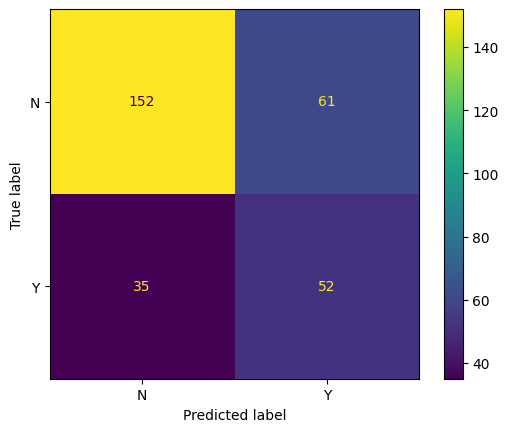

In [50]:
# Examine the evaluation results on testing data: confusion_matrix
cm_NB = confusion_matrix(target_test, prediction_on_test_NB)
ConfusionMatrixDisplay(confusion_matrix=cm_NB, display_labels=model_NB.classes_).plot()

In [51]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score
print(classification_report(target_test, prediction_on_test_NB))

              precision    recall  f1-score   support

           N       0.81      0.71      0.76       213
           Y       0.46      0.60      0.52        87

    accuracy                           0.68       300
   macro avg       0.64      0.66      0.64       300
weighted avg       0.71      0.68      0.69       300



The performance of the Multinomial Naive Bayes model is relatively poor because its assumptions are not well suited to the dataset. Multinomial Naive Bayes is designed for count-based features, such as text data, whereas this dataset contains mostly continuous variables like income, tenure, and usage measures.

Additionally, the model assumes independence between features, but many variables in the dataset are highly correlated, which violates this assumption and reduces performance. The presence of class imbalance further affects the model, leading to lower precision for the churn class.

Overall, the simplicity of the Naive Bayes model and the mismatch between its assumptions and the data structure contribute to its weaker performance compared to other models.

## IV. MLP Model Prediction

In [88]:
#Build MLP model contains two hidden layers: 64 hidden nodes for the first layer, 16 hidden nodes for the second layer, and 8 hidden nodes for the third layer. Set random_state=1. (0.5 points)

model_MLP1 = MLPClassifier(hidden_layer_sizes=(64,16,8), activation='relu', random_state=1)
model_MLP1.fit(predictors_train, target_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(64, 16, 8), random_state=1)

In [89]:
# Make predictions on testing data (0.5 points)
prediction_on_test = model_MLP1.predict(predictors_test)

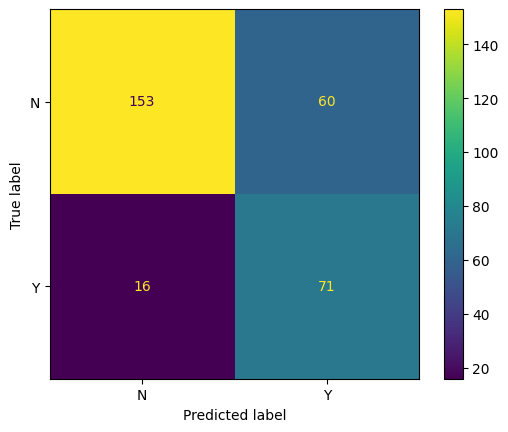

In [90]:
# Examine the evaluation results on testing data: confusion_matrix (0.5 points)

cm_MLP1 = confusion_matrix(target_test, prediction_on_test)
ConfusionMatrixDisplay(confusion_matrix=cm_MLP1, display_labels=model_MLP1.classes_).plot()

In [91]:
# Examine the evaluation results on testing data: accuracy, precision, recall, and f1-score (0.5 points)
print(classification_report(target_test, prediction_on_test))

              precision    recall  f1-score   support

           N       0.91      0.72      0.80       213
           Y       0.54      0.82      0.65        87

    accuracy                           0.75       300
   macro avg       0.72      0.77      0.73       300
weighted avg       0.80      0.75      0.76       300



# **5. Evaluation**

The top performing decision tree model can be used to identify customers who are likely to churn. By analyzing customer background information and service characteristics, the telecom company can predict which customers are at risk of discontinuing their service. These predictions enable the company to implement targeted retention strategies, such as personalized promotions, loyalty incentives, or enhanced customer support. Rather than applying retention efforts broadly and potentially wasting resources, the company can focus specifically on high-risk customers, result in efficiency and reducing potential revenue loss.

Although the model is not perfect and still misses some churn cases, it provides valuable insights that support decision-making in customer retention management. Its interpretability also makes it practical for business use, as managers can understand the key factors influencing churn. With further improvements, such as addressing class imbalance or incorporating additional predictive variables, the model's ability to detect churn could be enhanced, leading to more effective and targeted retention strategies.